
# Figure 1: Spatial Information in U.S. County Maps

This notebook reproduces all panels used in Figure 1 and organizes them into a single, publication-facing workflow. It consolidates the analysis that was previously spread across:

- `01a_US_counties_map.ipynb`
- `01b_US_counties_percolation.ipynb`
- `01c_toy_model.ipynb`

The notebook has three goals:

1. Build the county-level input data used throughout the figure.
2. Generate and save each panel as a standalone file with publication-ready styling.
3. Assemble the saved panels into a single composite figure.

The panel geometry and styling follow the original notebooks as closely as possible while making the code easier to read and reuse.



## Imports and Global Settings

The figure depends on `geopandas` for geometry handling and `GraphPercolation` for the entropy-based percolation analysis.


In [1]:

from pathlib import Path
from textwrap import fill
import os
import tempfile
import warnings

import colorcet as cc
import geopandas as gpd
import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import urllib3
from matplotlib.colors import ListedColormap, Normalize
from matplotlib.cm import ScalarMappable

from max_info_atlases.percolation.graph_percolation import GraphPercolation

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'
pd.options.mode.chained_assignment = None
warnings.filterwarnings('ignore', category=UserWarning, message='Geometry is in a geographic CRS')
warnings.filterwarnings('ignore', category=UserWarning, module='matplotlib')
warnings.filterwarnings('ignore', category=DeprecationWarning, module='matplotlib')
warnings.filterwarnings('ignore', category=UserWarning, module='shapely')
warnings.filterwarnings('ignore', category=DeprecationWarning, module='shapely')
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

NOTEBOOK_DIR = Path.cwd()
DATA_DIR = (NOTEBOOK_DIR / '../Data').resolve()
FIGURE_DIR = (NOTEBOOK_DIR / '../Figures').resolve()
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MAP_SIZE = (1.93, 0.82)
PANEL_B_SIZE = (4.0, 2.0)
PANEL_D_SIZE = (2.75, 1.8)
PANEL_E_SIZE = (1.2, 0.9)
PANEL_F_SIZE = (2.5, 1.5)
PANEL_G_SIZE = (1.35, 0.8)
PANEL_H_SIZE = (1.35, 0.9)
FINAL_FIG_SIZE = (14.5, 10.2)

custom_cmap_fips = ListedColormap(['#74a16c', 'green'])
custom_cmap_gdp = ListedColormap(['#919ac7', 'blue'])
custom_cmap_temp = ListedColormap(['#c28f8a', 'brown'])



## Helper Functions

These helpers keep the notebook linear and make it easier to reuse panel code in the final composite figure.


In [2]:

STATE_FIPS_TO_NAME = {
    '01': 'Alabama', '04': 'Arizona', '05': 'Arkansas', '06': 'California',
    '08': 'Colorado', '09': 'Connecticut', '10': 'Delaware', '11': 'District of Columbia',
    '12': 'Florida', '13': 'Georgia', '16': 'Idaho', '17': 'Illinois',
    '18': 'Indiana', '19': 'Iowa', '20': 'Kansas', '21': 'Kentucky',
    '22': 'Louisiana', '23': 'Maine', '24': 'Maryland', '25': 'Massachusetts',
    '26': 'Michigan', '27': 'Minnesota', '28': 'Mississippi', '29': 'Missouri',
    '30': 'Montana', '31': 'Nebraska', '32': 'Nevada', '33': 'New Hampshire',
    '34': 'New Jersey', '35': 'New Mexico', '36': 'New York', '37': 'North Carolina',
    '38': 'North Dakota', '39': 'Ohio', '40': 'Oklahoma', '41': 'Oregon',
    '42': 'Pennsylvania', '44': 'Rhode Island', '45': 'South Carolina', '46': 'South Dakota',
    '47': 'Tennessee', '48': 'Texas', '49': 'Utah', '50': 'Vermont',
    '51': 'Virginia', '53': 'Washington', '54': 'West Virginia', '55': 'Wisconsin',
    '56': 'Wyoming'
}

CENSUS_REGIONS = {
    '09': 'Northeast', '23': 'Northeast', '25': 'Northeast', '33': 'Northeast',
    '34': 'Northeast', '36': 'Northeast', '42': 'Northeast', '44': 'Northeast', '50': 'Northeast',
    '17': 'Midwest', '18': 'Midwest', '19': 'Midwest', '20': 'Midwest', '26': 'Midwest',
    '27': 'Midwest', '29': 'Midwest', '31': 'Midwest', '38': 'Midwest', '39': 'Midwest',
    '46': 'Midwest', '55': 'Midwest',
    '01': 'South', '05': 'South', '10': 'South', '11': 'South', '12': 'South', '13': 'South',
    '21': 'South', '22': 'South', '24': 'South', '28': 'South', '37': 'South', '40': 'South',
    '45': 'South', '47': 'South', '48': 'South', '51': 'South', '54': 'South',
    '04': 'West', '06': 'West', '08': 'West', '16': 'West', '30': 'West', '32': 'West',
    '35': 'West', '41': 'West', '49': 'West', '53': 'West', '56': 'West'
}

CENSUS_DIVISIONS = {
    '09': 'New England', '23': 'New England', '25': 'New England', '33': 'New England',
    '44': 'New England', '50': 'New England',
    '34': 'Middle Atlantic', '36': 'Middle Atlantic', '42': 'Middle Atlantic',
    '17': 'East North Central', '18': 'East North Central', '26': 'East North Central',
    '39': 'East North Central', '55': 'East North Central',
    '19': 'West North Central', '20': 'West North Central', '27': 'West North Central',
    '29': 'West North Central', '31': 'West North Central', '38': 'West North Central', '46': 'West North Central',
    '10': 'South Atlantic', '11': 'South Atlantic', '12': 'South Atlantic', '13': 'South Atlantic',
    '24': 'South Atlantic', '37': 'South Atlantic', '45': 'South Atlantic', '51': 'South Atlantic', '54': 'South Atlantic',
    '01': 'East South Central', '21': 'East South Central', '28': 'East South Central', '47': 'East South Central',
    '05': 'West South Central', '22': 'West South Central', '40': 'West South Central', '48': 'West South Central',
    '04': 'Mountain', '08': 'Mountain', '16': 'Mountain', '30': 'Mountain',
    '32': 'Mountain', '35': 'Mountain', '49': 'Mountain', '56': 'Mountain',
    '06': 'Pacific', '41': 'Pacific', '53': 'Pacific'
}

STATE_TO_FIPS = {
    'AL': '01', 'AK': '02', 'AZ': '04', 'AR': '05', 'CA': '06', 'CO': '08', 'CT': '09',
    'DE': '10', 'FL': '12', 'GA': '13', 'HI': '15', 'ID': '16', 'IL': '17', 'IN': '18',
    'IA': '19', 'KS': '20', 'KY': '21', 'LA': '22', 'ME': '23', 'MD': '24', 'MA': '25',
    'MI': '26', 'MN': '27', 'MS': '28', 'MO': '29', 'MT': '30', 'NE': '31', 'NV': '32',
    'NH': '33', 'NJ': '34', 'NM': '35', 'NY': '36', 'NC': '37', 'ND': '38', 'OH': '39',
    'OK': '40', 'OR': '41', 'PA': '42', 'RI': '44', 'SC': '45', 'SD': '46', 'TN': '47',
    'TX': '48', 'UT': '49', 'VT': '50', 'VA': '51', 'WA': '53', 'WV': '54', 'WI': '55',
    'WY': '56', 'DC': '11'
}

EXCLUDE_STATES = ['02', '15', '72', '66', '78', '60', '69', '74']


def save_figure(fig, stem):
    pdf_path = FIGURE_DIR / f'{stem}.pdf'
    png_path = FIGURE_DIR / f'{stem}.png'
    fig.savefig(pdf_path, format='pdf', dpi=300, bbox_inches='tight')
    fig.savefig(png_path, format='png', dpi=300, bbox_inches='tight')
    return pdf_path, png_path


def load_lower_48_counties():
    url = 'https://www2.census.gov/geo/tiger/GENZ2020/shp/cb_2020_us_county_500k.zip'
    response = requests.get(url, verify=False, timeout=120)
    response.raise_for_status()
    with tempfile.NamedTemporaryFile(delete=False, suffix='.zip') as tmp_file:
        tmp_file.write(response.content)
        tmp_path = tmp_file.name
    try:
        counties = gpd.read_file(tmp_path)
    finally:
        os.unlink(tmp_path)

    counties['STATE_FIPS'] = counties['GEOID'].str[:2]
    counties['STATE'] = counties['STATE_FIPS'].map(STATE_FIPS_TO_NAME)
    counties['REGION'] = counties['STATE_FIPS'].map(CENSUS_REGIONS)
    counties['DIVISION'] = counties['STATE_FIPS'].map(CENSUS_DIVISIONS)

    lower_48 = counties.loc[~counties['STATE_FIPS'].isin(EXCLUDE_STATES)].copy()
    centroids = lower_48.geometry.centroid
    lower_48['X'] = centroids.x
    lower_48['Y'] = centroids.y
    return lower_48


def load_gdp_data():
    economic_data = pd.read_csv(DATA_DIR / 'CAGDP1__ALL_AREAS_2001_2023.csv', encoding='latin1')
    economic_data = economic_data.loc[economic_data['LineCode'] == 1].copy()
    economic_data = economic_data.drop(columns=['LineCode', 'Description'], errors='ignore')
    economic_data = economic_data.rename(columns={'GeoFIPS': 'GEOID'})
    economic_data['GEOID'] = economic_data['GEOID'].astype(str).str.replace('"', '', regex=False).str.strip().str.zfill(5)
    return economic_data


def convert_fips_label(value):
    if pd.isna(value):
        return None
    state_abbr, _, county_code = str(value).partition('-')
    state_fips = STATE_TO_FIPS.get(state_abbr)
    if not state_fips or not county_code:
        return None
    return state_fips + county_code.zfill(3)


def load_temperature_data():
    temperature_df = pd.read_csv(DATA_DIR / 'temperature.csv', comment='#')
    temperature_df = temperature_df.rename(columns={'ID': 'FIPS', 'Value': 'Temp'})
    temperature_df['GEOID'] = temperature_df['FIPS'].apply(convert_fips_label)
    return temperature_df


def sum_of_digits_even_or_odd(county_fp):
    digit_sum = sum(int(digit) for digit in str(county_fp))
    return 1 if digit_sum % 2 == 0 else 0


def build_analysis_table():
    lower_48 = load_lower_48_counties()
    lower_48['FIPS_is_even'] = lower_48['COUNTYFP'].apply(sum_of_digits_even_or_odd)

    lower_48 = lower_48.merge(load_gdp_data(), on='GEOID', how='left')
    lower_48['GDP>median'] = lower_48['2023'].astype(float) > lower_48['2023'].astype(float).median()

    lower_48 = lower_48.merge(load_temperature_data(), on='GEOID', how='left', validate='one_to_one')
    lower_48['Temp>median'] = lower_48['Temp'].astype(float) > lower_48['Temp'].astype(float).median()

    result = lower_48[['GEOID', 'NAME', 'STATE', 'REGION', 'DIVISION', 'X', 'Y',
                       'FIPS_is_even', 'Temp', 'Temp>median', '2023', 'GDP>median']].copy()
    result = result.rename(columns={'2023': 'GDP'})
    result.to_csv(DATA_DIR / 'lower_48_data_for_percolation.csv', index=False)
    return lower_48, result


def plot_binary_map(ax, geodf, column, cmap):
    geodf.plot(column=column, ax=ax, legend=False, cmap=cmap, edgecolor='none', linewidth=0, rasterized=True)
    ax.set_axis_off()
    ax.set_aspect('equal')


def plot_categorical_map(ax, geodf, column, palette):
    unique_values = list(pd.unique(geodf[column]))
    color_lookup = {value: palette[i] for i, value in enumerate(unique_values)}
    geodf.plot(ax=ax, color=geodf[column].map(color_lookup), edgecolor='gray', linewidth=0.01, rasterized=True)
    ax.set_axis_off()
    ax.set_aspect('equal')


def save_stacked_maps(geodf, columns, cmaps_or_colors, stem, categorical=False):
    fig, axes = plt.subplots(len(columns), 1, figsize=(MAP_SIZE[0], MAP_SIZE[1] * len(columns)))
    if len(columns) == 1:
        axes = [axes]
    for ax, column, style in zip(axes, columns, cmaps_or_colors):
        if categorical:
            plot_categorical_map(ax, geodf, column, style)
        else:
            plot_binary_map(ax, geodf, column, style)
    fig.tight_layout(h_pad=0.05)
    save_figure(fig, stem)
    return fig


def encode_series(series):
    codes, _ = pd.factorize(series, sort=False)
    return codes.astype(np.int32)


def run_percolation(points, series):
    gp = GraphPercolation(points, encode_series(series))
    gp.percolation()
    return gp


def plot_entropy_panel(ax, gps, colors, labels, draw_min=False):
    for gp, color, label in zip(gps, colors, labels):
        ax.plot(gp.pbond_vec[:-1], gp.ent_real, '-', color=color, linewidth=1.0)
        ax.plot(gp.pbond_vec[:-1], gp.ent_perm, ':', color=color, linewidth=1.0)
    ax.set_ylabel('Map Information', fontsize=7)
    ax.set_xlabel('Proximity', fontsize=7)
    ax.set_xticks([0, 1])
    ax.set_ylim(0, 15)
    ax.set_yticks([0, 5, 10, 15])
    ax.tick_params(axis='both', labelsize=7)
    ax.grid(False)
    ax.xaxis.set_label_coords(0.5, -0.05)


def plot_bar_panel(ax, labels, values, colors):
    ax.bar(labels, values, color=colors)
    ax.set_ylabel('Map Information', fontsize=7)
    ax.tick_params(axis='x', labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.grid(False)


def H_of_p(p, N_cells, N_types, p0=0.2, delta=0.1, gamma=0.005):
    H_max = np.log2(N_cells)
    delta_h = np.log2(N_cells / N_types)
    p_c = p0 + gamma * np.sqrt(N_cells / N_types)
    sigma = 1 / (1 + np.exp(-(p - p_c) / delta))
    return H_max - delta_h * sigma, p_c


def integrated_score(N_cells, N_types, p0=0.2, delta=0.1, gamma=0.005):
    delta_h = np.log2(N_cells / N_types)
    p_c = p0 + gamma * np.sqrt(N_cells / N_types)
    return delta_h * delta * (np.log(1 + np.exp((1 - p_c) / delta)) - np.log(1 + np.exp(-p_c / delta)))


def draw_panel_image(ax, path, label):
    ax.imshow(mpimg.imread(path))
    ax.axis('off')
    ax.text(-0.03, 1.03, label, transform=ax.transAxes, fontsize=14, fontweight='bold', va='bottom')



## County-Level Data Assembly

This step downloads county boundaries for the contiguous United States, joins the GDP and temperature covariates, and saves the percolation input table used in the remaining panels.


In [3]:

lower_48, result = build_analysis_table()
points = result[['X', 'Y']].to_numpy()

print(f'Lower-48 counties: {len(lower_48):,}')
print(f'Saved percolation table: {DATA_DIR / "lower_48_data_for_percolation.csv"}')
result.head()


Lower-48 counties: 3,108
Saved percolation table: /home/rwollman/MyProjects/MaxInfoCart/Data/lower_48_data_for_percolation.csv


,GEOID,NAME,STATE,REGION,DIVISION,X,Y,FIPS_is_even,Temp,Temp>median,GDP,GDP>median
0,13031,Bulloch,Georgia,South,South Atlantic,-81.743167,32.396810,1,49.1,True,2740304,True
1,13121,Fulton,Georgia,South,South Atlantic,-84.467010,33.790244,1,41.7,True,198475810,True
2,13179,Liberty,Georgia,South,South Atlantic,-81.494900,31.828233,0,50.4,True,3910016,True
3,13189,McDuffie,Georgia,South,South Atlantic,-82.481391,33.482830,1,45.3,True,705983,False
4,13213,Murray,Georgia,South,South Atlantic,-84.748072,34.788430,1,37.9,True,1496145,True



## Panel A: Binary County Maps


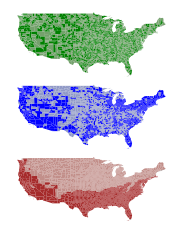

In [4]:

panel_a = save_stacked_maps(
    lower_48,
    columns=['FIPS_is_even', 'GDP>median', 'Temp>median'],
    cmaps_or_colors=[custom_cmap_fips, custom_cmap_gdp, custom_cmap_temp],
    stem='Figure1_panel_a',
    categorical=False,
)
plt.show()



## Panels B and C: Percolation Curves and Information Scores for Binary Maps


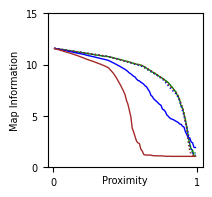

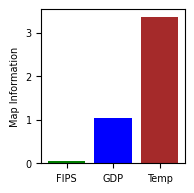

In [5]:

analysis_columns = ['FIPS_is_even', 'GDP>median', 'Temp>median', 'STATE', 'DIVISION', 'REGION']
percolation_results = {column: run_percolation(points, result[column]) for column in analysis_columns}

binary_labels = ['FIPS', 'GDP', 'Temp']
binary_colors = ['green', 'blue', 'brown']
binary_gps = [percolation_results[column] for column in analysis_columns[:3]]

fig_b, ax_b = plt.subplots(figsize=(2, 2.0))
plot_entropy_panel(ax_b, binary_gps, binary_colors, binary_labels, draw_min=False)
save_figure(fig_b, 'Figure1_panel_b')
plt.show()

fig_c, ax_c = plt.subplots(figsize=(1.85, 2.0))
binary_scores = [gp.score() for gp in binary_gps]
plot_bar_panel(ax_c, binary_labels, binary_scores, binary_colors)
save_figure(fig_c, 'Figure1_panel_c')
plt.show()



## Panels D and E: Temperature Quantile Sweep

The temperature panel is recomputed across threshold quantiles to illustrate how class balance affects the information score.


In [ ]:

quantiles = np.linspace(0, 1, 11)
quantile_gps = []
for q in quantiles:
    type_binary = result['Temp'] > result['Temp'].quantile(q)
    quantile_gps.append(run_percolation(points, type_binary))
quantile_scores = [gp.score() for gp in quantile_gps]
quantile_colors = plt.cm.coolwarm(np.linspace(0, 1, len(quantiles)))

fig_d, ax_d = plt.subplots(figsize=PANEL_D_SIZE)
middle_idx = len(quantile_gps) // 2
ax_d.plot(
    quantile_gps[middle_idx].pbond_vec[:-1],
    quantile_gps[middle_idx].ent_perm,
    'k-',
    linewidth=1,
    alpha=0.7,
)
for gp, q, color in zip(quantile_gps, quantiles, quantile_colors):
    ax_d.plot(gp.pbond_vec[:-1], gp.ent_real, '-', color=color, linewidth=0.75)
ax_d.set_ylim(0, 15)
ax_d.set_yticks([0, 5, 10, 15])
ax_d.set_xlabel('Proximity', fontsize=7)
ax_d.set_ylabel('Map Information', fontsize=7)
ax_d.set_xticks([0, 1])
ax_d.tick_params(axis='both', labelsize=7)
ax_d.grid(False)
ax_d.xaxis.set_label_coords(0.5, -0.05)
save_figure(fig_d, 'Figure1_panel_d')
plt.show()

fig_e, ax_e = plt.subplots(figsize=PANEL_E_SIZE)
ax_e.plot(quantiles * 100, quantile_scores, '-', color='gray', linewidth=0.8, alpha=0.8)
ax_e.scatter(quantiles * 100, quantile_scores, c=quantile_colors, s=28, linewidth=0.4)
ax_e.set_xlabel('Temp Quantile', fontsize=7)
ax_e.set_ylabel('Map Information', fontsize=7)
ax_e.tick_params(axis='both', labelsize=7)
ax_e.grid(False)
save_figure(fig_e, 'Figure1_panel_e')
plt.show()



## Panels F, G, and H: Toy Model for Type Granularity


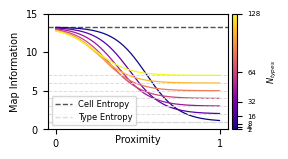

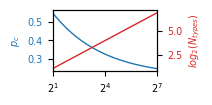

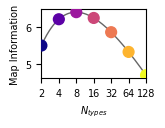

In [ ]:

N_cells = 10000
p0 = 0.2
delta = 0.1
gamma = 0.005
p_vals = np.linspace(0, 1, 200)
N_types_list = [2, 4, 8, 16, 32, 64, 128]
N_types_arr = np.logspace(1, 7, 200, base=2)
plasma_colors = plt.cm.plasma(np.linspace(0, 1, len(N_types_list)))
H_max = np.log2(N_cells)
p_cs = [p0 + gamma * np.sqrt(N_cells / nt) for nt in N_types_arr]
log2_N_types = np.log2(N_types_arr)
continuous_scores = [integrated_score(N_cells, nt, p0, delta, gamma) for nt in N_types_arr]
score_points = [integrated_score(N_cells, nt, p0, delta, gamma) for nt in N_types_list]

fig_f, ax_f = plt.subplots(figsize=PANEL_F_SIZE)
ax_f.axhline(H_max, color='0.25', linestyle='--', linewidth=1.0, alpha=0.9, label='Cell Entropy')
ax_f.axhline(np.log2(N_types_list[0]), color='0.85', linestyle='--', linewidth=1.0, alpha=0.9, label='Type Entropy')
for color, N_types in zip(plasma_colors, N_types_list):
    H_vals, _ = H_of_p(p_vals, N_cells, N_types, p0, delta, gamma)
    ax_f.plot(p_vals, H_vals, color=color, linewidth=0.9)
    ax_f.axhline(np.log2(N_types), color='0.85', linestyle='--', linewidth=0.7, alpha=0.9)
ax_f.set_xticks([0, 1])
ax_f.set_ylim(0, 15)
ax_f.set_xlabel('Proximity', fontsize=7)
ax_f.set_ylabel('Map Information', fontsize=7)
ax_f.tick_params(axis='both', labelsize=7)
ax_f.grid(False)
ax_f.xaxis.set_label_coords(0.5, -0.05)
ax_f.legend(loc='lower left', fontsize=6)
sm = ScalarMappable(norm=Normalize(vmin=min(N_types_list), vmax=max(N_types_list)), cmap='plasma')
sm.set_array([])
cbar = fig_f.colorbar(sm, ax=ax_f, fraction=0.05, pad=0.02)
cbar.set_label('$N_{types}$', fontsize=6)
cbar.ax.tick_params(labelsize=5)
cbar.set_ticks(N_types_list)
save_figure(fig_f, 'Figure1_panel_f')
plt.show()

fig_g, ax_g = plt.subplots(figsize=PANEL_G_SIZE)
ax_g.set_xscale('log', base=2)
ax_g.plot(N_types_arr, p_cs, color='tab:blue', linewidth=1.0)
ax_g.set_xlim(2, 128)
ax_g.set_ylabel('$p_c$', color='tab:blue', fontsize=7)
ax_g.tick_params(axis='x', labelsize=7)
ax_g.tick_params(axis='y', labelsize=7, labelcolor='tab:blue')
ax_g.set_xticks([2, 4, 8, 16, 32, 64, 128])
ax_g.set_xticklabels([])
ax_g2 = ax_g.twinx()
ax_g2.set_xscale('log', base=2)
ax_g2.plot(N_types_arr, log2_N_types, color='tab:red', linewidth=1.0)
ax_g2.set_ylabel('$log_2(N_{types})$', color='tab:red', fontsize=7)
ax_g2.tick_params(axis='y', labelsize=7, labelcolor='tab:red')
ax_g.grid(False)
save_figure(fig_g, 'Figure1_panel_g')
plt.show()

fig_h, ax_h = plt.subplots(figsize=PANEL_H_SIZE)
ax_h.plot(N_types_arr, continuous_scores, color='0.4', linewidth=1.0)
ax_h.scatter(N_types_list, score_points, c=plasma_colors, s=60, zorder=3)
ax_h.set_xscale('log', base=2)
ax_h.set_xlim(2, 128)
ax_h.set_xticks([2, 4, 8, 16, 32, 64, 128])
ax_h.set_xticklabels([2, 4, 8, 16, 32, 64, 128])
ax_h.set_xlabel('$N_{types}$', fontsize=7)
ax_h.set_ylabel('Map Information', fontsize=7)
ax_h.tick_params(axis='both', labelsize=7)
ax_h.grid(False)
save_figure(fig_h, 'Figure1_panel_h')
plt.show()



## Panel I: Census Hierarchy Maps


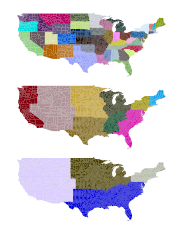

In [ ]:

base_palette = list(cc.glasbey_bw)
rng = np.random.default_rng(42)
base_palette = list(np.array(base_palette)[rng.permutation(len(base_palette))])

state_palette = [base_palette[i] for i in range(lower_48['STATE'].nunique())]
division_palette = [base_palette[i + lower_48['STATE'].nunique()] for i in range(lower_48['DIVISION'].nunique())]
region_palette = [base_palette[i + lower_48['STATE'].nunique() + lower_48['DIVISION'].nunique()] for i in range(lower_48['REGION'].nunique())]

panel_i = save_stacked_maps(
    lower_48,
    columns=['STATE', 'DIVISION', 'REGION'],
    cmaps_or_colors=[state_palette, division_palette, region_palette],
    stem='Figure1_panel_i',
    categorical=True,
)
plt.show()



## Panels J and K: Percolation Across Geographic Hierarchies


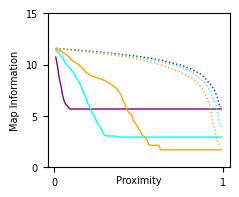

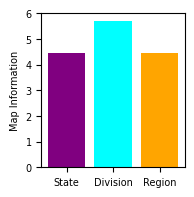

In [ ]:

hierarchy_labels = ['State', 'Division', 'Region']
hierarchy_colors = ['purple', 'cyan', 'orange']
hierarchy_gps = [percolation_results[column] for column in analysis_columns[3:]]

fig_j, ax_j = plt.subplots(figsize=(2, 2.0))
plot_entropy_panel(ax_j, hierarchy_gps, hierarchy_colors, hierarchy_labels, draw_min=False)
save_figure(fig_j, 'Figure1_panel_j')
plt.show()

fig_k, ax_k = plt.subplots(figsize=(1.85, 2.0))
hierarchy_scores = [gp.score() for gp in hierarchy_gps]
plot_bar_panel(ax_k, hierarchy_labels, hierarchy_scores, hierarchy_colors)
save_figure(fig_k, 'Figure1_panel_k')
plt.show()



## Final Composite Figure

The composite figure is built from the saved standalone panel images so the exact panel exports are reused in the final layout.


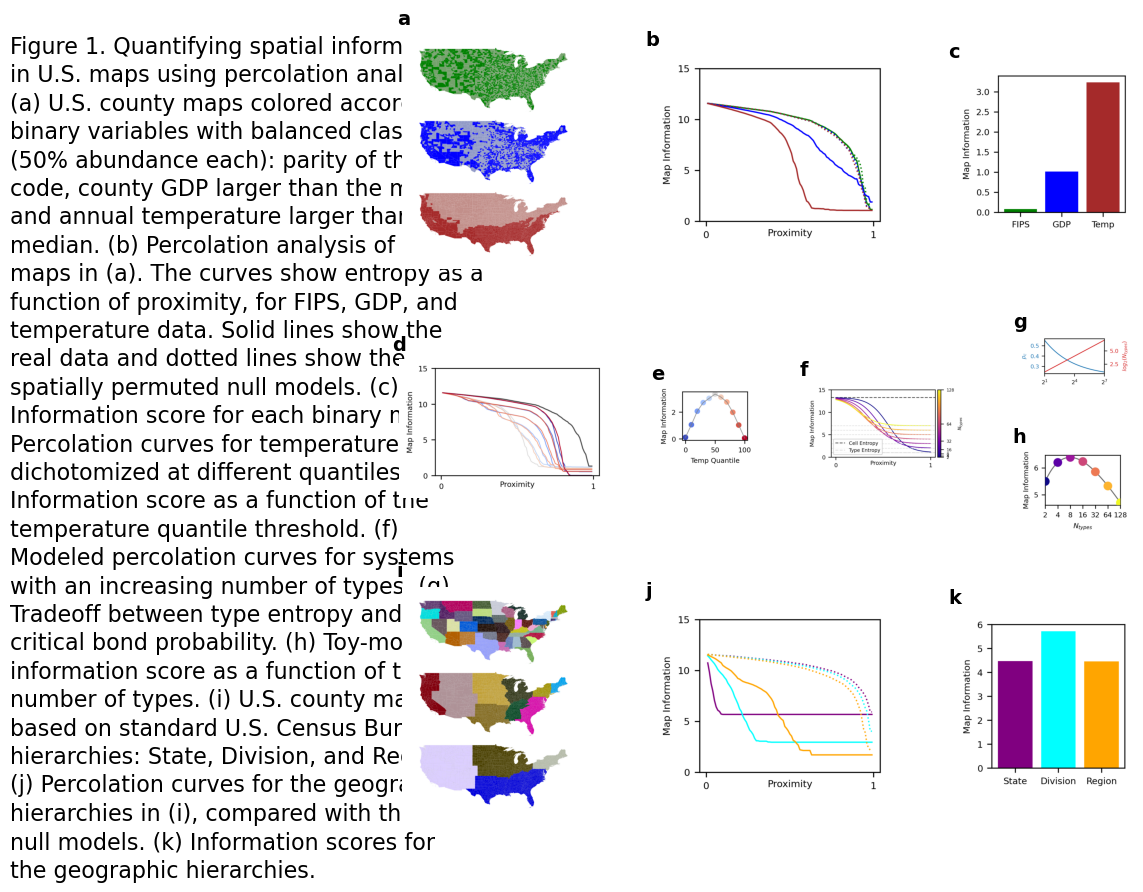

In [ ]:

caption_text = (
    'Figure 1. Quantifying spatial information in U.S. maps using percolation analysis. '
    '(a) U.S. county maps colored according to binary variables with balanced classes (50% abundance each): '
    'parity of the FIPS code, county GDP larger than the median, and annual temperature larger than the median. '
    '(b) Percolation analysis of the maps in (a). The curves show entropy as a function of proximity, '
    'for FIPS, GDP, and temperature data. Solid lines show the real data and dotted lines show the spatially permuted null models. '
    '(c) Information score for each binary map. (d) Percolation curves for temperature maps dichotomized at different quantiles. '
    '(e) Information score as a function of the temperature quantile threshold. (f) Modeled percolation curves for systems with an increasing number of types. '
    '(g) Tradeoff between type entropy and the critical bond probability. (h) Toy-model information score as a function of the number of types. '
    '(i) U.S. county maps based on standard U.S. Census Bureau hierarchies: State, Division, and Region. '
    '(j) Percolation curves for the geographic hierarchies in (i), compared with their null models. '
    '(k) Information scores for the geographic hierarchies.'
)

panel_paths = {label: FIGURE_DIR / f'Figure1_panel_{label}.png' for label in 'abcdefghijk'}

fig = plt.figure(figsize=FINAL_FIG_SIZE)
outer = fig.add_gridspec(
    3,
    2,
    width_ratios=[1.15, 2.6],
    height_ratios=[1.0, 1.0, 1.0],
    wspace=0.12,
    hspace=0.18,
)

ax_caption = fig.add_subplot(outer[:, 0])
ax_caption.axis('off')
ax_caption.text(0.0, 1.0, fill(caption_text, 42), va='top', ha='left', fontsize=16, linespacing=1.3)

row1 = outer[0, 1].subgridspec(1, 3, width_ratios=[1.0, 1.25, 0.95], wspace=0.32)
row2 = outer[1, 1].subgridspec(1, 4, width_ratios=[1.45, 0.72, 1.15, 0.82], wspace=0.32)
row3 = outer[2, 1].subgridspec(1, 3, width_ratios=[1.0, 1.25, 0.95], wspace=0.32)
gh = row2[3].subgridspec(2, 1, hspace=0.28)

axes = {
    'a': fig.add_subplot(row1[0]),
    'b': fig.add_subplot(row1[1]),
    'c': fig.add_subplot(row1[2]),
    'd': fig.add_subplot(row2[0]),
    'e': fig.add_subplot(row2[1]),
    'f': fig.add_subplot(row2[2]),
    'g': fig.add_subplot(gh[0]),
    'h': fig.add_subplot(gh[1]),
    'i': fig.add_subplot(row3[0]),
    'j': fig.add_subplot(row3[1]),
    'k': fig.add_subplot(row3[2]),
}

for label, ax in axes.items():
    draw_panel_image(ax, panel_paths[label], label)

save_figure(fig, 'Figure1')
plt.show()



## Generated Files

Running the notebook produces:

- `../Data/lower_48_data_for_percolation.csv`
- `../Figures/Figure1_panel_a` through `../Figures/Figure1_panel_k` as both PDF and PNG
- `../Figures/Figure1.pdf`
- `../Figures/Figure1.png`
